In [8]:
from SLBlensing import SLBlensing
from astropy import units as u
import numpy as np

# WD lens
mass_wd  = 0.634
r_wd = 0.01166
l_wd = 0.00120
t_wd = 10000
lds_wd = [.35, .18]

# Sun-like star
mass_s = 1.0 
r_s = 1.0
l_s = 1.0
T_eff_s = 5778
lds_s = [0.44, 0.23]
tg_s = 0.32

# orbital parameters
d = 500.0 * u.pc
inc_deg  = 90 * u.deg
omega_deg = 0 * u.deg  

N = 1000000

In [9]:
binary = SLBlensing(
        mass_wd, r_wd, l_wd, t_wd, 
        mass_s, r_s, l_s, T_eff_s, 
        ecc=0.05, a=2.0 * u.AU, d=d, omega=omega_deg,
        inc=inc_deg,
        limb_darkening_l=lds_wd, limb_darkening_star=lds_s, gravity_darkening=tg_s,
        N=N
    )

In [10]:
# print statements of self variables
print(f"Period: {binary.P:.4}")
print(f"Einstein Radius: {binary.r_E}")
print(f"LOS Velocity Lens: {binary.v_lens_los}")
print(f"LOS Velocity Star: {binary.v_star_los}")

Period: 2.213 yr
Einstein Radius: [31838646.11692423 31838646.11694256 31838646.11699753 ...
 31838646.11699753 31838646.11694256 31838646.11692423] m
LOS Velocity Lens: [17321.47749675 17321.47749635 17321.47749515 ... 17321.47749515
 17321.47749635 17321.47749675] m / s
LOS Velocity Star: [10981.81673294 10981.81673268 10981.81673193 ... 10981.81673193
 10981.81673268 10981.81673294] m / s


In [11]:
# find eclipse duration
binary.eclipse_duration()
print(f"Total Transit Time: {binary.tra_tot.to(u.hr):.4}")
print(f"Transit Time w/o Ingress/Egress: {binary.tra_full.to(u.hr):.4}")
print(f"Transit Ingress Time: {binary.tra_ingress.to(u.hr):.4}")
print(f"Transit Egress Time: {binary.tra_egress.to(u.hr):.4}")
print(" --------------- ")
print(f"Total Occultation Time: {binary.oc_tot.to(u.hr):.4}")
print(f"Occultation Time w/o Ingress/Egress: {binary.oc_full.to(u.hr):.4}")
print(f"Occultation Ingress Time: {binary.oc_ingress.to(u.hr):.4}")
print(f"Occultation Egress Time: {binary.oc_egress.to(u.hr):.4}")

Total Transit Time: 14.51 h
Transit Time w/o Ingress/Egress: 14.17 h
Transit Ingress Time: 0.1672 h
Transit Egress Time: 0.1672 h
 --------------- 
Total Occultation Time: 14.51 h
Occultation Time w/o Ingress/Egress: 14.17 h
Occultation Ingress Time: 0.1672 h
Occultation Egress Time: 0.1672 h


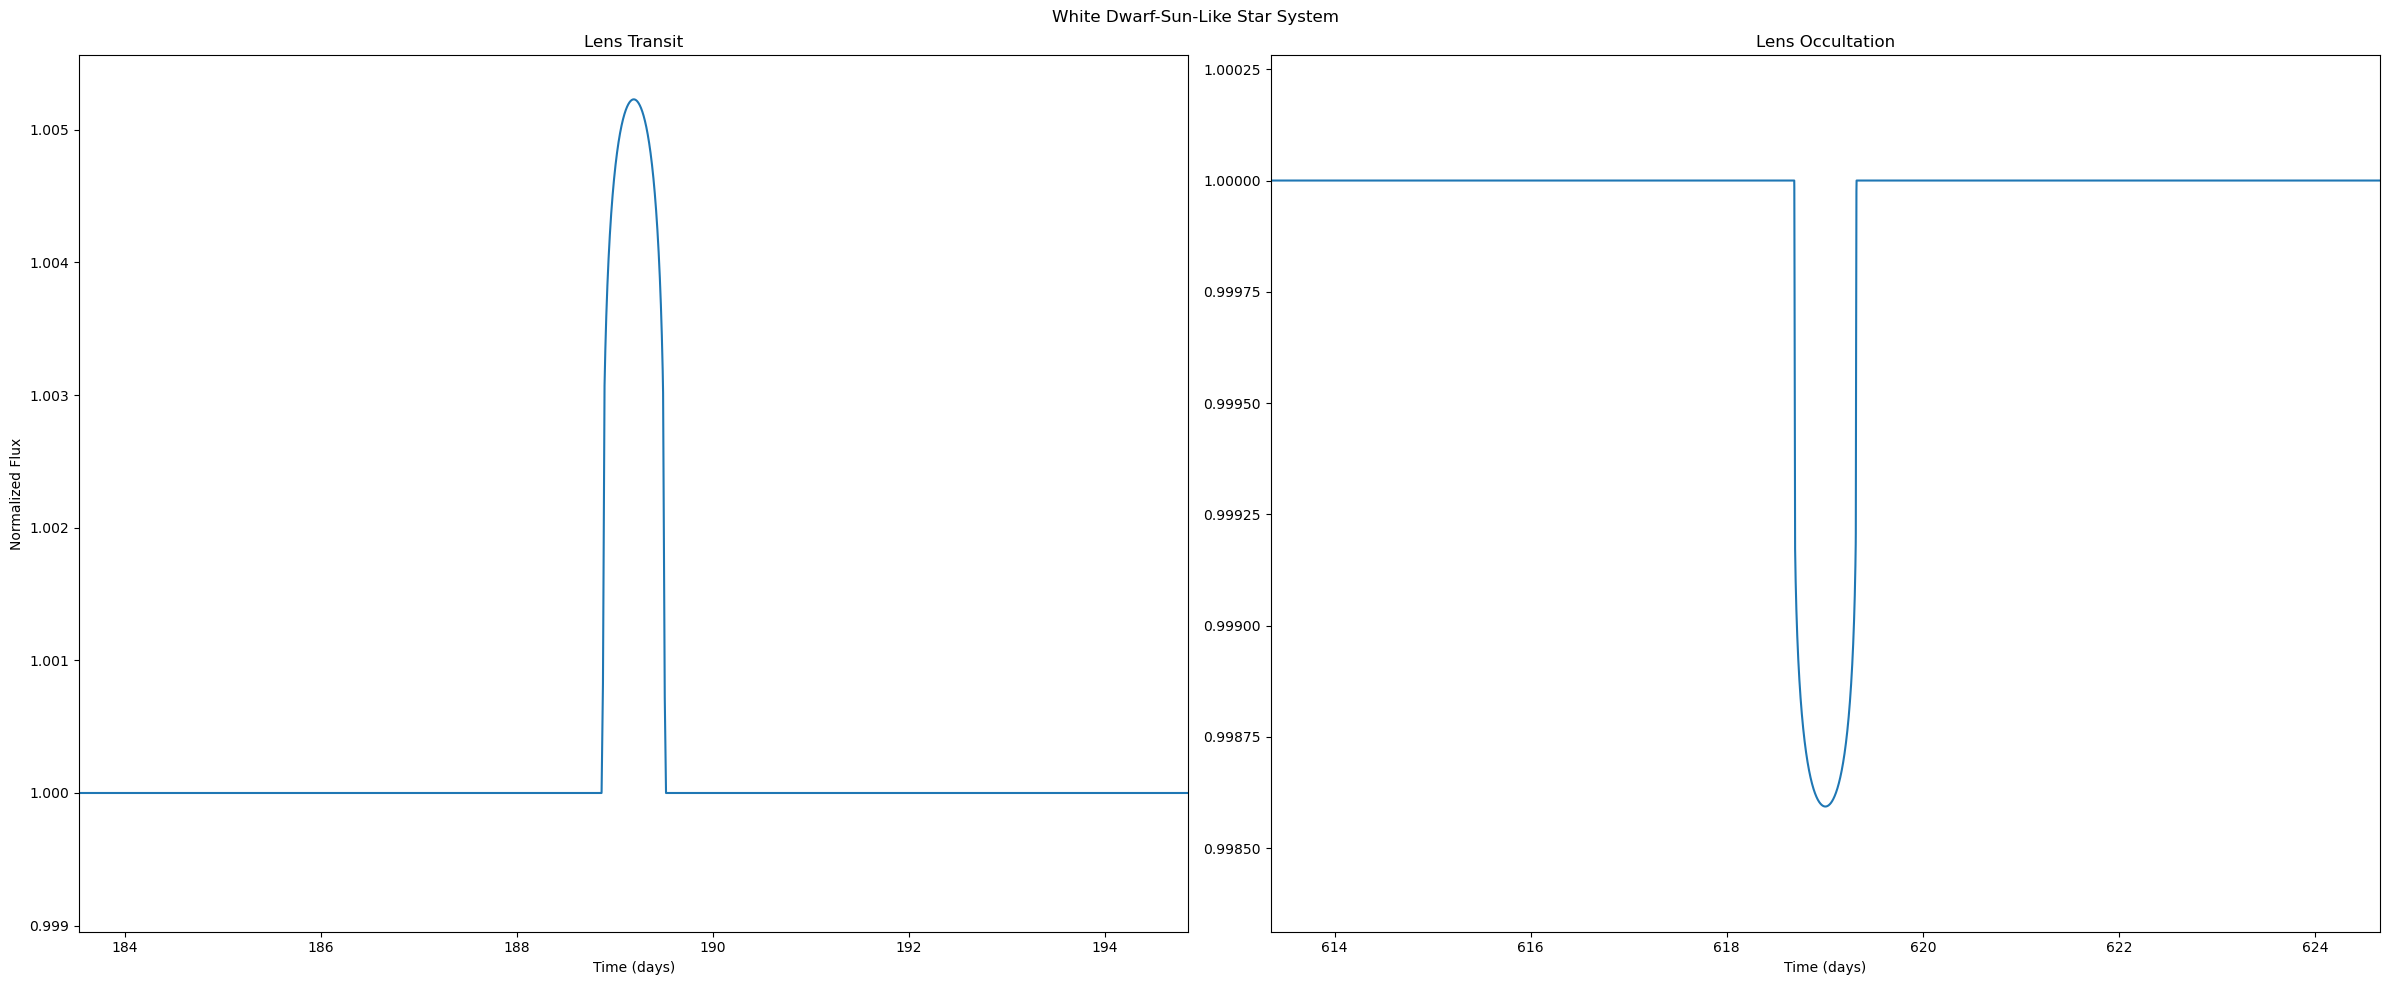

In [12]:
binary.light_curve_plotter("White Dwarf-Sun-Like Star System", 0.007)

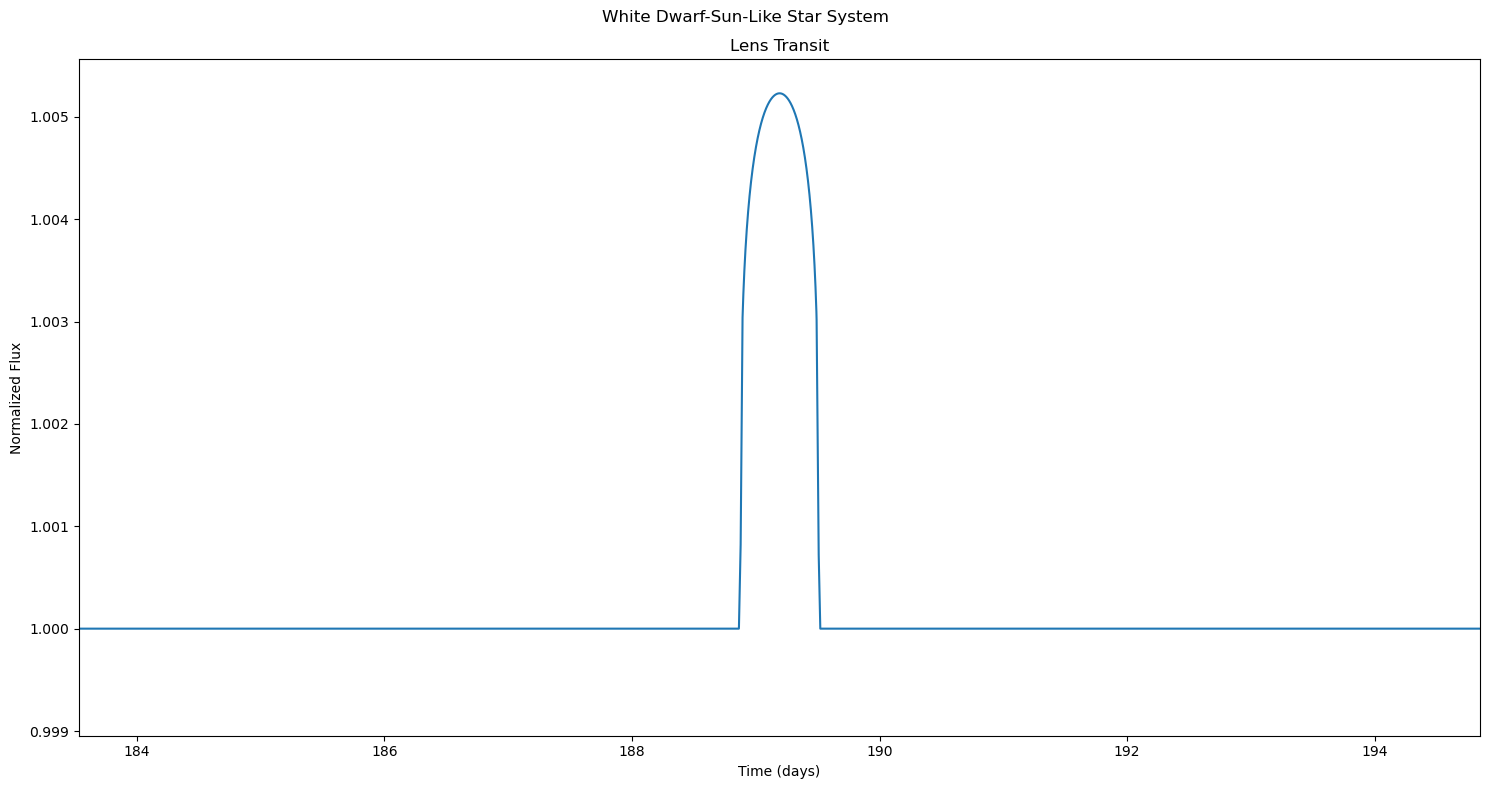

In [13]:
binary.transit_plotter("White Dwarf-Sun-Like Star System", 0.007)

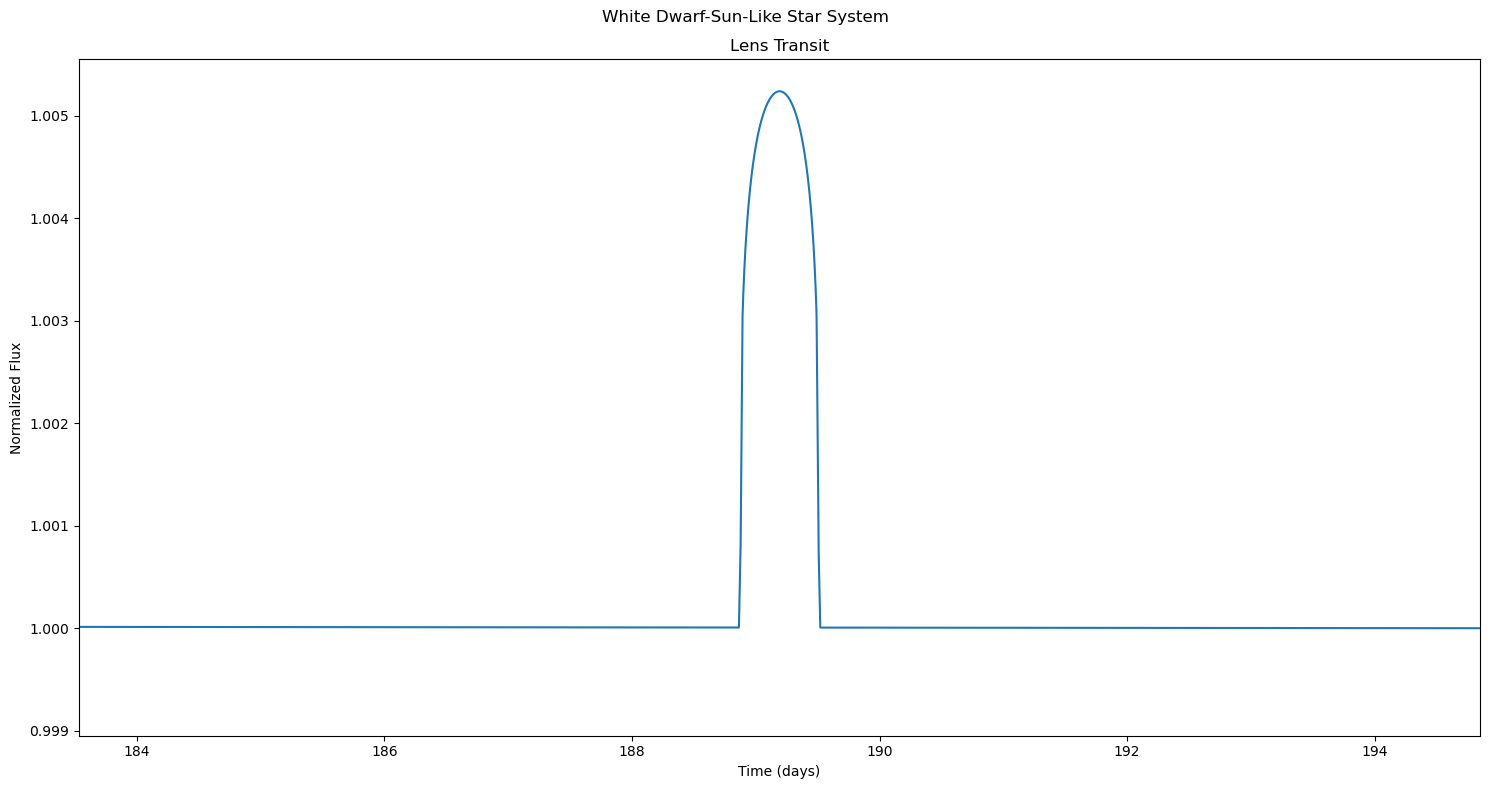

In [14]:
binary_w_freq = SLBlensing(
        mass_wd, r_wd, l_wd, t_wd, 
        mass_s, r_s, l_s, T_eff_s, 
        ecc=0.05, a=2.0 * u.AU, d=d, omega=omega_deg,
        inc=inc_deg,
        limb_darkening_l=lds_wd, limb_darkening_star=lds_s, gravity_darkening=tg_s, freq=5e14 * u.Hz,
        N=N
    )

binary_w_freq.transit_plotter("White Dwarf-Sun-Like Star System", 0.007)